In [2]:
import numpy as np
import pandas as pd
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv('mental_health_dataset.csv')

In [8]:
data.head()

,Age,Gender,Occupation,Sleep_Hours,Social_Interaction,Physical_Activity,Stress_Level,Mood,Appetite_Change,Anxiety_Score,Depression_Score,Mental_Health_Status
0,25,Male,Engineer,6,Low,Moderate,8,3,Yes,7,6,Anxiety
1,30,Female,Teacher,5,Moderate,Low,9,2,Yes,9,8,Depression
2,22,Non-Binary,Student,7,High,High,4,7,No,3,2,Healthy
3,40,Male,Doctor,4,Low,Low,10,1,Yes,8,9,Depression
4,35,Female,Freelancer,8,High,Moderate,3,8,No,2,1,Healthy


In [10]:
sleep = ctrl.Antecedent(np.arange(0, 11, 1), 'sleep')
social = ctrl.Antecedent(np.arange(0, 11, 1), 'social')
activity = ctrl.Antecedent(np.arange(0, 11, 1), 'activity')
stress = ctrl.Antecedent(np.arange(0, 11, 1), 'stress')
mood = ctrl.Antecedent(np.arange(0, 11, 1), 'mood')

In [7]:
mental_health = ctrl.Consequent(np.arange(0, 11, 1), 'mental_health')

In [41]:
# Corrected sleep membership functions definition
sleep['very_low'] = fuzz.trapmf(sleep.universe, [0, 0, 2, 4])
sleep['low'] = fuzz.trimf(sleep.universe, [3, 4, 5])
sleep['moderate'] = fuzz.trimf(sleep.universe, [4, 6, 7])
sleep['high'] = fuzz.trimf(sleep.universe, [6, 8, 9])
sleep['very_high'] = fuzz.trapmf(sleep.universe, [8, 9, 10, 10])
# For sleep
sleep['irregular'] = fuzz.trimf(sleep.universe, [2, 4, 6])
sleep['delayed'] = fuzz.trimf(sleep.universe, [4, 6, 8])
sleep['fragmented'] = fuzz.trimf(sleep.universe, [3, 5, 7])

# For mood

# Now these should match exactly what we use in the rules

In [11]:
social['low'] = fuzz.trapmf(social.universe, [0, 0, 2, 4])
social['moderate'] = fuzz.trimf(social.universe, [3, 5, 7])
social['high'] = fuzz.trapmf(social.universe, [6, 8, 10, 10])

In [12]:
# Physical activity (0-10 scale)
activity['low'] = fuzz.trapmf(activity.universe, [0, 0, 2, 4])
activity['moderate'] = fuzz.trimf(activity.universe, [3, 5, 7])
activity['high'] = fuzz.trapmf(activity.universe, [6, 8, 10, 10])

# Stress level (0-10 scale)
stress['low'] = fuzz.trapmf(stress.universe, [0, 0, 2, 4])
stress['moderate'] = fuzz.trimf(stress.universe, [3, 5, 7])
stress['high'] = fuzz.trapmf(stress.universe, [6, 8, 10, 10])

# Mood (0-10 scale)
mood['low'] = fuzz.trapmf(mood.universe, [0, 0, 2, 4])
mood['moderate'] = fuzz.trimf(mood.universe, [3, 5, 7])
mood['high'] = fuzz.trapmf(mood.universe, [6, 8, 10, 10])
mood['fluctuating'] = fuzz.trimf(mood.universe, [3, 5, 7])
mood['irritable'] = fuzz.trimf(mood.universe, [2, 4, 6])


In [44]:
mental_health['severe_depression'] = fuzz.trapmf(mental_health.universe, [0, 0, 2, 4])
mental_health['depression'] = fuzz.trimf(mental_health.universe, [3, 4, 5])
mental_health['mild_depression'] = fuzz.trimf(mental_health.universe, [4, 5, 6])
mental_health['anxiety'] = fuzz.trimf(mental_health.universe, [5, 6, 7])
mental_health['mild_anxiety'] = fuzz.trimf(mental_health.universe, [6, 7, 8])
mental_health['healthy'] = fuzz.trapmf(mental_health.universe, [7, 8, 10, 10])

# New output categories for additional conditions
mental_health['anxiety_depression'] = fuzz.trimf(mental_health.universe, [4.5, 5.5, 6.5])
mental_health['situational_stress'] = fuzz.trimf(mental_health.universe, [5, 6, 7])
mental_health['acute_anxiety'] = fuzz.trimf(mental_health.universe, [6, 7, 8]) 
mental_health['burnout'] = fuzz.trimf(mental_health.universe, [3, 4, 5])
mental_health['adjustment_disorder'] = fuzz.trimf(mental_health.universe, [4, 5, 6])
mental_health['high_functioning_anxiety'] = fuzz.trimf(mental_health.universe, [6, 7, 8])
mental_health['smiling_depression'] = fuzz.trimf(mental_health.universe, [4, 5, 6])


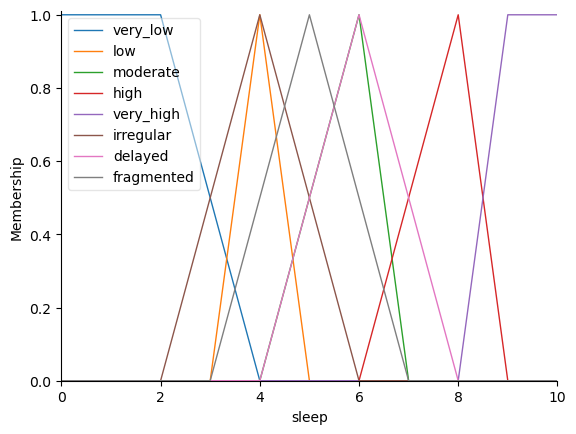

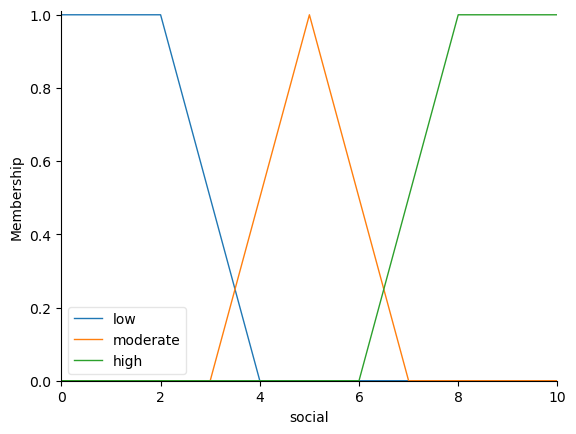

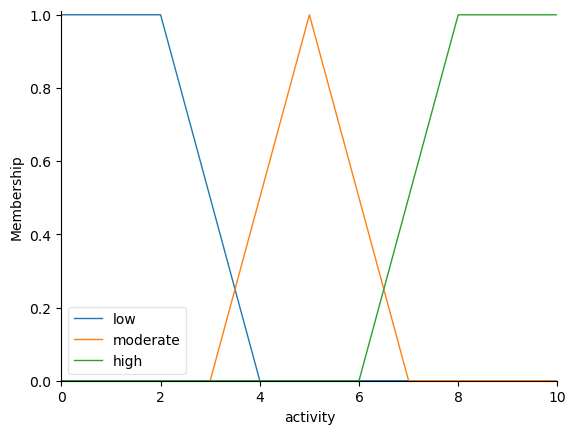

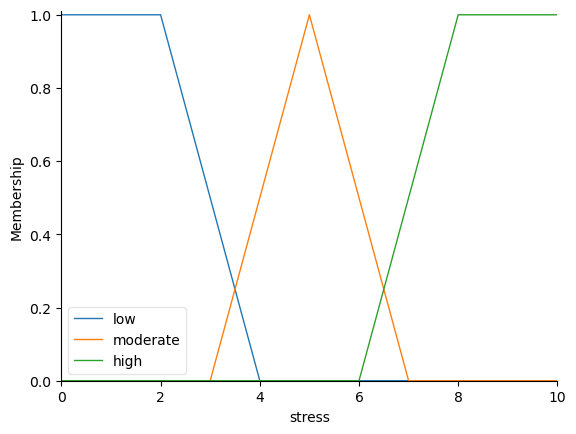

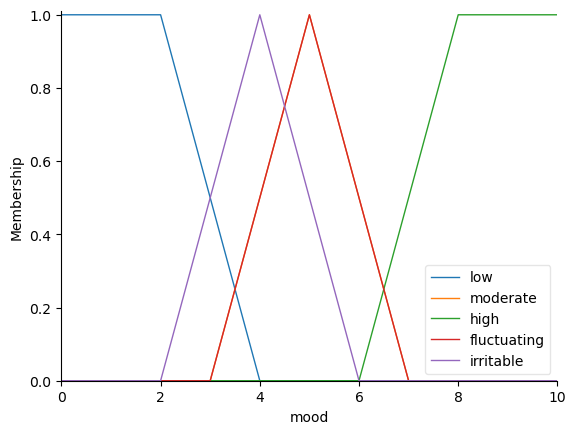

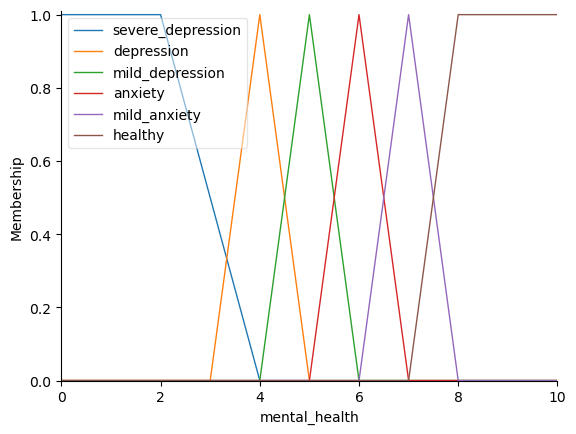

In [43]:
sleep.view()
social.view()
activity.view()
stress.view()
mood.view()
mental_health.view()
plt.show()

In [46]:
# 1. Severe Depression Rules
rules = [
    # Very low sleep + low social + low activity + high stress + low mood
    ctrl.Rule(sleep['very_low'] & social['low'] & activity['low'] & stress['high'] & mood['low'], 
             mental_health['severe_depression']),
    
    # Very low sleep + low social + moderate activity + high stress + low mood
    ctrl.Rule(sleep['very_low'] & social['low'] & activity['moderate'] & stress['high'] & mood['low'], 
             mental_health['severe_depression']),
    
    # Very low sleep + moderate social + low activity + high stress + low mood
    ctrl.Rule(sleep['very_low'] & social['moderate'] & activity['low'] & stress['high'] & mood['low'], 
             mental_health['severe_depression']),
]

# 2. Depression Rules
rules += [
    # Low sleep + low social + low activity + high stress + low mood
    ctrl.Rule(sleep['low'] & social['low'] & activity['low'] & stress['high'] & mood['low'], 
             mental_health['depression']),
    
    # Moderate sleep + low social + low activity + high stress + low mood
    ctrl.Rule(sleep['moderate'] & social['low'] & activity['low'] & stress['high'] & mood['low'], 
             mental_health['depression']),
    
    # Low sleep + moderate social + low activity + high stress + low mood
    ctrl.Rule(sleep['low'] & social['moderate'] & activity['low'] & stress['high'] & mood['low'], 
             mental_health['depression']),
    
    # Low sleep + low social + moderate activity + high stress + low mood
    ctrl.Rule(sleep['low'] & social['low'] & activity['moderate'] & stress['high'] & mood['low'], 
             mental_health['depression']),
]

# 3. Mild Depression Rules
rules += [
    # Moderate sleep + moderate social + moderate activity + moderate stress + moderate mood
    ctrl.Rule(sleep['moderate'] & social['moderate'] & activity['moderate'] & stress['moderate'] & mood['moderate'], 
             mental_health['mild_depression']),
    
    # High sleep + moderate social + moderate activity + moderate stress + moderate mood
    ctrl.Rule(sleep['high'] & social['moderate'] & activity['moderate'] & stress['moderate'] & mood['moderate'], 
             mental_health['mild_depression']),
    
    # Moderate sleep + high social + moderate activity + moderate stress + moderate mood
    ctrl.Rule(sleep['moderate'] & social['high'] & activity['moderate'] & stress['moderate'] & mood['moderate'], 
             mental_health['mild_depression']),
]

# 4. Anxiety Rules
rules += [
    # Moderate sleep + moderate social + moderate activity + high stress + moderate mood
    ctrl.Rule(sleep['moderate'] & social['moderate'] & activity['moderate'] & stress['high'] & mood['moderate'], 
             mental_health['anxiety']),
    
    # High sleep + moderate social + moderate activity + high stress + moderate mood
    ctrl.Rule(sleep['high'] & social['moderate'] & activity['moderate'] & stress['high'] & mood['moderate'], 
             mental_health['anxiety']),
    
    # Moderate sleep + high social + moderate activity + high stress + moderate mood
    ctrl.Rule(sleep['moderate'] & social['high'] & activity['moderate'] & stress['high'] & mood['moderate'], 
             mental_health['anxiety']),
]

# 5. Mild Anxiety Rules
rules += [
    # High sleep + moderate social + moderate activity + moderate stress + high mood
    ctrl.Rule(sleep['high'] & social['moderate'] & activity['moderate'] & stress['moderate'] & mood['high'], 
             mental_health['mild_anxiety']),
    
    # High sleep + high social + moderate activity + moderate stress + high mood
    ctrl.Rule(sleep['high'] & social['high'] & activity['moderate'] & stress['moderate'] & mood['high'], 
             mental_health['mild_anxiety']),
    
    # Very high sleep + moderate social + moderate activity + moderate stress + high mood
    ctrl.Rule(sleep['very_high'] & social['moderate'] & activity['moderate'] & stress['moderate'] & mood['high'], 
             mental_health['mild_anxiety']),
]

# 6. Healthy Rules
rules += [
    # High sleep + high social + high activity + low stress + high mood
    ctrl.Rule(sleep['high'] & social['high'] & activity['high'] & stress['low'] & mood['high'], 
             mental_health['healthy']),
    
    # Very high sleep + high social + high activity + low stress + high mood
    ctrl.Rule(sleep['very_high'] & social['high'] & activity['high'] & stress['low'] & mood['high'], 
             mental_health['healthy']),
    
    # Moderate sleep + high social + high activity + low stress + high mood
    ctrl.Rule(sleep['moderate'] & social['high'] & activity['high'] & stress['low'] & mood['high'], 
             mental_health['healthy']),
    
    # High sleep + moderate social + high activity + low stress + high mood
    ctrl.Rule(sleep['high'] & social['moderate'] & activity['high'] & stress['low'] & mood['high'], 
             mental_health['healthy']),
    
    # High sleep + high social + moderate activity + low stress + high mood
    ctrl.Rule(sleep['high'] & social['high'] & activity['moderate'] & stress['low'] & mood['high'], 
             mental_health['healthy']),
]

# 7. Edge Cases and Special Conditions
rules += [
    # Good sleep but other factors poor → still depression
    ctrl.Rule(sleep['high'] & social['low'] & activity['low'] & stress['high'] & mood['low'], 
             mental_health['depression']),
    
    # Poor sleep but other factors good → mild anxiety
    ctrl.Rule(sleep['low'] & social['high'] & activity['high'] & stress['low'] & mood['high'], 
             mental_health['mild_anxiety']),
    
    # High stress but other factors good → anxiety
    ctrl.Rule(sleep['high'] & social['high'] & activity['high'] & stress['high'] & mood['high'], 
             mental_health['anxiety']),
]
rules += [
   
    ctrl.Rule(sleep['low'] & social['moderate'] & activity['low'] & stress['high'] & mood['moderate'],
             mental_health['anxiety_depression']),
    
    ctrl.Rule(sleep['moderate'] & social['low'] & activity['moderate'] & stress['high'] & mood['low'],
             mental_health['anxiety_depression']),
    
    ctrl.Rule(sleep['moderate'] & social['high'] & activity['high'] & stress['high'] & mood['moderate'],
             mental_health['situational_stress']),
    
    
]

# Create control system with all rules
mental_health_ctrl = ctrl.ControlSystem(rules)
mental_health_sim = ctrl.ControlSystemSimulation(mental_health_ctrl)

In [25]:
def predict_mental_health(age, gender, occupation, sleep_hours, social_interaction, 
                          physical_activity, stress_level, mood_score):
    # Create a fresh simulation every time
    sim = ctrl.ControlSystemSimulation(mental_health_ctrl)

    # Preprocess inputs
    sleep_input = (sleep_hours / 12) * 10  # Normalize to 0-10 scale
    
    social_map = {'low': 3, 'moderate': 6, 'high': 9}
    activity_map = {'low': 3, 'moderate': 6, 'high': 9}
    
    try:
        social_input = social_map[social_interaction.lower()]
        activity_input = activity_map[physical_activity.lower()]
    except KeyError as e:
        print(f"Invalid input: {e}")
        return "Invalid Input"

    sim.input['sleep'] = sleep_input
    sim.input['social'] = social_input
    sim.input['activity'] = activity_input
    sim.input['stress'] = stress_level
    sim.input['mood'] = mood_score

    try:
        sim.compute()
        output_value = sim.output['mental_health']
    except Exception as e:
        print(f"Fuzzy computation error: {e}")
        return "Error in prediction"

    # Map output to category
    if output_value <= 3:
        return "Severe Depression"
    elif output_value <= 4.5:
        return "Depression"
    elif output_value <= 5.5:
        return "Mild Depression"
    elif output_value <= 6.5:
        return "Anxiety"
    elif output_value <= 7.5:
        return "Mild Anxiety"
    return "Healthy"



In [29]:
def get_user_input():
    """Function to collect all required inputs from the user"""
    print("\n=== Mental Health Assessment ===")
    print("Please answer the following questions:\n")
    
    # Basic information
    age = int(input("1. Your age: "))
    gender = input("2. Your gender (Male/Female/Non-Binary): ").capitalize()
    occupation = input("3. Your occupation: ").capitalize()
    
    # Sleep patterns
    print("\nSleep Patterns:")
    sleep_hours = float(input("4. Average hours of sleep per night (0-12): "))
    while sleep_hours < 0 or sleep_hours > 12:
        print("Please enter a value between 0 and 12")
        sleep_hours = float(input("Average hours of sleep per night (0-12): "))
    
    # Social interaction
    print("\nSocial Interaction (Low/Moderate/High):")
    social_interaction = input("5. Level of social interaction: ").capitalize()
    while social_interaction not in ['Low', 'Moderate', 'High']:
        print("Please enter Low, Moderate, or High")
        social_interaction = input("Level of social interaction: ").capitalize()
    
    # Physical activity
    print("\nPhysical Activity (Low/Moderate/High):")
    physical_activity = input("6. Level of physical activity: ").capitalize()
    while physical_activity not in ['Low', 'Moderate', 'High']:
        print("Please enter Low, Moderate, or High")
        physical_activity = input("Level of physical activity: ").capitalize()
    
    # Stress and mood
    print("\nOn a scale from 1-10:")
    stress_level = int(input("7. Your stress level (1-10): "))
    while stress_level < 1 or stress_level > 10:
        print("Please enter a value between 1 and 10")
        stress_level = int(input("Your stress level (1-10): "))
    
    mood_score = int(input("8. Your mood score (1-10, where 10 is best): "))
    while mood_score < 1 or mood_score > 10:
        print("Please enter a value between 1 and 10")
        mood_score = int(input("Your mood score (1-10): "))
    
    return {
        'Age': age,
        'Gender': gender,
        'Occupation': occupation,
        'Sleep_Hours': sleep_hours,
        'Social_Interaction': social_interaction,
        'Physical_Activity': physical_activity,
        'Stress_Level': stress_level,
        'Mood': mood_score
    }

    


In [58]:
user_data = get_user_input()


=== Mental Health Assessment ===
Please answer the following questions:



1. Your age:  30
2. Your gender (Male/Female/Non-Binary):  female
3. Your occupation:  student



Sleep Patterns:


4. Average hours of sleep per night (0-12):  12



Social Interaction (Low/Moderate/High):


5. Level of social interaction:  high



Physical Activity (Low/Moderate/High):


6. Level of physical activity:  high



On a scale from 1-10:


7. Your stress level (1-10):  1
8. Your mood score (1-10, where 10 is best):  10


In [59]:
    prediction = predict_mental_health(
        user_data['Age'],
        user_data['Gender'],
        user_data['Occupation'],
        user_data['Sleep_Hours'],
        user_data['Social_Interaction'],
        user_data['Physical_Activity'],
        user_data['Stress_Level'],
        user_data['Mood']
    )
    
    # Display results
    print("\n=== Assessment Results ===")
    print(f"Predicted Mental Health Status: {prediction}")


=== Assessment Results ===
Predicted Mental Health Status: Healthy
